<a href="https://colab.research.google.com/github/Evenjlin/deep-space-interference-ml/blob/main/notebooks/08_mitigation_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# Cell 1 — self-contained bootstrap
from google.colab import userdata
import torch, os, sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_EMAIL = "evenjlinekka@gmail.com"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/Evenjlin/deep-space-interference-ml.git"

if not os.path.exists('/content/deep-space-interference-ml'):
    !git clone {REPO_URL} /content/deep-space-interference-ml
%cd /content/deep-space-interference-ml
!git config --global user.email "{GITHUB_EMAIL}"
!git config --global user.name "Evenjlin"
!git remote set-url origin {REPO_URL}
!git pull

!pip install -r requirements.txt -q
sys.path.insert(0, os.getcwd())

Device: cuda
/content/deep-space-interference-ml
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 543 bytes | 543.00 KiB/s, done.
From https://github.com/Evenjlin/deep-space-interference-ml
   e682027..349c137  main       -> origin/main
Updating e682027..349c137
Fast-forward
 src/model.py | 28 +++++++++++++---------------
 1 file changed, 13 insertions(+), 15 deletions(-)


In [17]:
# Cell 2 (updated) — denoising-only training data, N_SYMBOLS=256 per BASE-PAPER FACT
import numpy as np
import torch
from src.channel import SignalConfig, generate_soi, generate_noise
from src.model import MitigationAutoencoder, complex_to_channels

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = SignalConfig(fd_max=0.0)
rng = np.random.default_rng(42)

N_SYMBOLS = 256  # BASE-PAPER FACT: paper's stated window for the denoising-only AE
SNR_RANGE_TRAIN = (-15, 30)

def make_denoising_pair(cfg, n_symbols, snr_range, rng):
    s, bits, fd, phi_m = generate_soi(cfg, n_symbols, rng)
    w = generate_noise(len(s), rng)
    snr_db = rng.uniform(*snr_range)
    rho_snr = 10 ** (snr_db / 10)
    x = s + w / np.sqrt(rho_snr)
    return complex_to_channels(x).astype(np.float32), complex_to_channels(s).astype(np.float32)

M_TRAIN, M_VAL = 3000, 750
X_train = np.stack([make_denoising_pair(cfg, N_SYMBOLS, SNR_RANGE_TRAIN, rng)[0] for _ in range(M_TRAIN)])
Y_train = np.stack([make_denoising_pair(cfg, N_SYMBOLS, SNR_RANGE_TRAIN, rng)[1] for _ in range(M_TRAIN)])
X_val = np.stack([make_denoising_pair(cfg, N_SYMBOLS, SNR_RANGE_TRAIN, rng)[0] for _ in range(M_VAL)])
Y_val = np.stack([make_denoising_pair(cfg, N_SYMBOLS, SNR_RANGE_TRAIN, rng)[1] for _ in range(M_VAL)])
print("X_train:", X_train.shape)  # expect (3000, 2, 2048) -- 256 symbols x 8 NSPS

identity_mse_train = np.mean((X_train - Y_train) ** 2)
print(f"Identity baseline MSE (train): {identity_mse_train:.5f}")

X_train: (3000, 2, 2048)
Identity baseline MSE (train): 2.42506


In [18]:
# Cell 3 — DEBUG LADDER
model = MitigationAutoencoder(n_stages=2, n_hidden=32).to(device)
tiny_x = torch.tensor(X_train[:8], device=device)
out = model(tiny_x)
print("TEST 1: output shape", out.shape, " input shape", tiny_x.shape)
assert out.shape == tiny_x.shape

tiny_y = torch.tensor(Y_train[:8], device=device)
loss_fn = torch.nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=3e-5)  # BASE-PAPER FACT (mitigation AE lr)
loss = loss_fn(out, tiny_y); loss.backward(); opt.step(); opt.zero_grad()
print(f"TEST 2: one grad step OK, loss={loss.item():.4f}")

small_x = torch.tensor(X_train[:200], device=device)
small_y = torch.tensor(Y_train[:200], device=device)
losses = []
for _ in range(20):  # more steps than before -- lr=3e-5 is much smaller, needs more steps to visibly move
    opt.zero_grad()
    out = model(small_x)
    loss = loss_fn(out, small_y)
    loss.backward(); opt.step()
    losses.append(loss.item())
print("TEST 3/4 losses:", [f"{l:.4f}" for l in losses])
assert losses[-1] < losses[0], "Loss did not decrease -- stop, don't proceed"
print("Debug ladder PASSED.")

TEST 1: output shape torch.Size([8, 2, 2048])  input shape torch.Size([8, 2, 2048])
TEST 2: one grad step OK, loss=2.6656
TEST 3/4 losses: ['2.1775', '2.1730', '2.1686', '2.1642', '2.1600', '2.1559', '2.1518', '2.1478', '2.1438', '2.1397', '2.1355', '2.1313', '2.1270', '2.1226', '2.1182', '2.1138', '2.1094', '2.1050', '2.1006', '2.0964']
Debug ladder PASSED.


In [19]:
identity_mse_train = np.mean((X_train - Y_train) ** 2)
identity_mse_val = np.mean((X_val - Y_val) ** 2)
print(f"Identity baseline MSE (train): {identity_mse_train:.5f}")
print(f"Identity baseline MSE (val):   {identity_mse_val:.5f}")

Identity baseline MSE (train): 2.42506
Identity baseline MSE (val):   2.45443


In [20]:
# Cell 3c — confirm which version of forward() is ACTUALLY loaded right now
import inspect

src = inspect.getsource(MitigationAutoencoder.forward)
print(src)
print("---")
print("Has residual connection ('+ x'):", "+ x" in src.replace(" ", ""))

    def forward(self, x):
        h = self.first_conv(x)
        for layer in self.encoder:
            h = layer(h)
        for layer in self.decoder:
            h = layer(h)
        out = self.final_conv(h)
        if out.shape[-1] != x.shape[-1]:
            min_len = min(out.shape[-1], x.shape[-1])
            out = out[..., :min_len]
            x = x[..., :min_len]
        return out + x

---
Has residual connection ('+ x'): False


Epoch 1/100  train_loss=2.36401  val_loss=2.30264
Epoch 5/100  train_loss=1.92000  val_loss=1.93069
Epoch 10/100  train_loss=1.78517  val_loss=1.81251
Epoch 15/100  train_loss=1.69935  val_loss=1.71716
Epoch 20/100  train_loss=1.59752  val_loss=1.62054
Epoch 25/100  train_loss=1.48404  val_loss=1.52298
Epoch 30/100  train_loss=1.38016  val_loss=1.40061
Epoch 35/100  train_loss=1.30147  val_loss=1.30147
Epoch 40/100  train_loss=1.22617  val_loss=1.22346
Epoch 45/100  train_loss=1.15239  val_loss=1.15491
Epoch 50/100  train_loss=1.09039  val_loss=1.09621
Epoch 55/100  train_loss=1.03691  val_loss=1.04383
Epoch 60/100  train_loss=0.98995  val_loss=0.99208
Epoch 65/100  train_loss=0.93882  val_loss=0.94028
Epoch 70/100  train_loss=0.89184  val_loss=0.88992
Epoch 75/100  train_loss=0.84453  val_loss=0.84952
Epoch 80/100  train_loss=0.81279  val_loss=0.80997
Epoch 85/100  train_loss=0.77840  val_loss=0.79302
Epoch 90/100  train_loss=0.75365  val_loss=0.76687
Epoch 95/100  train_loss=0.72411 

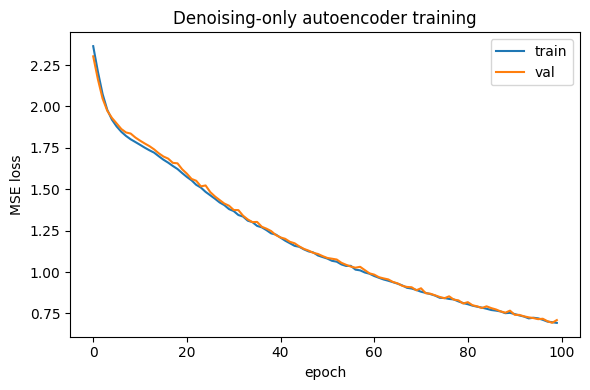

In [21]:
# Cell 4 — full training, denoising-only (SOI+noise, no interference)
def train_mitigation_ae(model, X_train, Y_train, X_val, Y_val, device,
                          epochs=100, batch_size=64, lr=3e-5, patience=10, seed=42):
    torch.manual_seed(seed)
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    Xt = torch.tensor(X_train, device=device)
    Yt = torch.tensor(Y_train, device=device)
    Xv = torch.tensor(X_val, device=device)
    Yv = torch.tensor(Y_val, device=device)

    history = {"train_loss": [], "val_loss": []}
    best_val, best_state, patience_ct = float("inf"), None, 0
    n = Xt.shape[0]

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        ep_losses = []
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            opt.zero_grad()
            out = model(Xt[idx])
            loss = loss_fn(out, Yt[idx])
            loss.backward(); opt.step()
            ep_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xv), Yv).item()

        train_loss = float(np.mean(ep_losses))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}  train_loss={train_loss:.5f}  val_loss={val_loss:.5f}")

        if val_loss < best_val:
            best_val, best_state, patience_ct = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_ct += 1
            if patience_ct >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    model.load_state_dict(best_state)
    return model, history

model_denoise = MitigationAutoencoder(n_stages=2, n_hidden=32)
model_denoise, history_denoise = train_mitigation_ae(model_denoise, X_train, Y_train, X_val, Y_val, device)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(history_denoise["train_loss"], label="train")
plt.plot(history_denoise["val_loss"], label="val")
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.legend()
plt.title("Denoising-only autoencoder training")
plt.tight_layout()
plt.savefig("figures/mitigation_ae_denoise_only_training.png", dpi=150)
plt.show()

import os
os.makedirs("checkpoints", exist_ok=True)
torch.save(model_denoise.state_dict(), "checkpoints/mitigation_ae_denoise_only.pt")

In [22]:
# Cell 4b — diagnostic retrain at a much larger LR, to test if lr=3e-5 was simply too small to escape the trivial solution
model_denoise_lr_test = MitigationAutoencoder(n_stages=2, n_hidden=32)
model_denoise_lr_test, history_lr_test = train_mitigation_ae(
    model_denoise_lr_test, X_train, Y_train, X_val, Y_val, device,
    epochs=100, lr=1e-3, patience=15  # OUR diagnostic: 30x paper's stated lr
)
print(f"Final val_loss at lr=1e-3: {history_lr_test['val_loss'][-1]:.5f}  (vs identity baseline {identity_mse_train:.5f}, vs 0.5 'output-zero' floor)")

Epoch 1/100  train_loss=2.04621  val_loss=1.88632
Epoch 5/100  train_loss=0.93058  val_loss=0.84924
Epoch 10/100  train_loss=0.55473  val_loss=0.54895
Epoch 15/100  train_loss=0.53572  val_loss=0.53767
Epoch 20/100  train_loss=0.52670  val_loss=0.53025
Epoch 25/100  train_loss=0.52363  val_loss=0.55047
Epoch 30/100  train_loss=0.52187  val_loss=0.52703
Epoch 35/100  train_loss=0.52921  val_loss=0.52327
Epoch 40/100  train_loss=0.54344  val_loss=0.52884
Epoch 45/100  train_loss=0.52676  val_loss=0.55211
Epoch 50/100  train_loss=0.53627  val_loss=0.53267
Epoch 55/100  train_loss=0.52316  val_loss=0.53015
Epoch 60/100  train_loss=0.51702  val_loss=0.52591
Epoch 65/100  train_loss=0.52138  val_loss=0.51904
Epoch 70/100  train_loss=0.51321  val_loss=0.51662
Epoch 75/100  train_loss=0.51598  val_loss=0.52560
Early stopping at epoch 76
Final val_loss at lr=1e-3: 0.51967  (vs identity baseline 2.42506, vs 0.5 'output-zero' floor)


Eb/N0=0dB  interference=0.3340  mitigated=0.4601  clean=0.1577  theoretical=0.0786
Eb/N0=1dB  interference=0.3242  mitigated=0.4751  clean=0.1306  theoretical=0.0563
Eb/N0=2dB  interference=0.3283  mitigated=0.4854  clean=0.1029  theoretical=0.0375
Eb/N0=3dB  interference=0.3180  mitigated=0.4889  clean=0.0806  theoretical=0.0229
Eb/N0=4dB  interference=0.3131  mitigated=0.4948  clean=0.0564  theoretical=0.0125
Eb/N0=5dB  interference=0.3178  mitigated=0.4913  clean=0.0388  theoretical=0.0060
Eb/N0=6dB  interference=0.3071  mitigated=0.4886  clean=0.0236  theoretical=0.0024


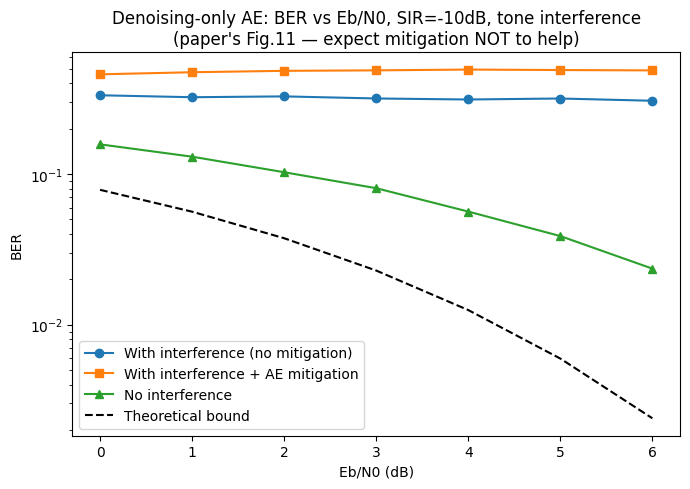

In [23]:
# Cell 5 — BER test: does DENOISING-ONLY autoencoder reduce BER against tone interference? (Fig.11/12)
from src.channel import mix_signal
from src.evaluate import matched_filter_ber, theoretical_ber

def ae_denoise(x_complex, model, device):
    channels = complex_to_channels(x_complex).astype(np.float32)
    with torch.no_grad():
        inp = torch.tensor(channels, device=device).unsqueeze(0)
        out = model(inp).squeeze(0).cpu().numpy()
    return out[0] + 1j*out[1]

SIR_DB_TEST = -10.0  # BASE-PAPER FACT (Fig.11 uses SIR=-10dB)
EBN0_RANGE = [0, 1, 2, 3, 4, 5, 6]  # BASE-PAPER FACT (Fig.11's x-axis range)
N_TRIALS = 300

ber_results = []
for ebn0_db in EBN0_RANGE:
    snr_db = ebn0_db - 10*np.log10(cfg.NSPS)  # invert our OUR ASSUMPTION Eb/N0<->SNR relationship

    ber_interference, ber_mitigated, ber_clean = [], [], []
    for _ in range(N_TRIALS):
        d = mix_signal(cfg, N_SYMBOLS, rng, interference_type="tone", contamination=1.0,
                        sir_db_range=(SIR_DB_TEST, SIR_DB_TEST), snr_db_range=(snr_db, snr_db),
                        apply_shift=False)
        x, bits, fd, phi_m, k_shift = d["x"], d["bits"], d["fd"], d["phi_m"], d["k_shift"]

        ber_interference.append(matched_filter_ber(x, bits, cfg, N_SYMBOLS, fd, phi_m, k_shift))

        x_mitigated = ae_denoise(x, model_denoise, device)
        ber_mitigated.append(matched_filter_ber(x_mitigated, bits, cfg, N_SYMBOLS, fd, phi_m, k_shift))

        d_clean = mix_signal(cfg, N_SYMBOLS, rng, interference_type="tone", contamination=0.0,
                              snr_db_range=(snr_db, snr_db), apply_shift=False)
        ber_clean.append(matched_filter_ber(d_clean["x"], d_clean["bits"], cfg, N_SYMBOLS,
                                              d_clean["fd"], d_clean["phi_m"], d_clean["k_shift"]))

    ber_results.append({
        "ebn0_db": ebn0_db,
        "ber_with_interference": np.mean(ber_interference),
        "ber_mitigated": np.mean(ber_mitigated),
        "ber_no_interference": np.mean(ber_clean),
        "ber_theoretical": theoretical_ber(ebn0_db),
    })
    print(f"Eb/N0={ebn0_db}dB  interference={np.mean(ber_interference):.4f}  "
          f"mitigated={np.mean(ber_mitigated):.4f}  clean={np.mean(ber_clean):.4f}  "
          f"theoretical={theoretical_ber(ebn0_db):.4f}")

import pandas as pd
ber_df = pd.DataFrame(ber_results)
ber_df.to_csv("results/step8_denoise_only_ber.csv", index=False)

import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.semilogy(ber_df["ebn0_db"], ber_df["ber_with_interference"], marker='o', label="With interference (no mitigation)")
plt.semilogy(ber_df["ebn0_db"], ber_df["ber_mitigated"], marker='s', label="With interference + AE mitigation")
plt.semilogy(ber_df["ebn0_db"], ber_df["ber_no_interference"], marker='^', label="No interference")
plt.semilogy(ber_df["ebn0_db"], ber_df["ber_theoretical"], linestyle='--', color='black', label="Theoretical bound")
plt.xlabel("Eb/N0 (dB)"); plt.ylabel("BER")
plt.title("Denoising-only AE: BER vs Eb/N0, SIR=-10dB, tone interference\n(paper's Fig.11 — expect mitigation NOT to help)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/step8_denoise_only_ber.png", dpi=150)
plt.show()

In [24]:
# Cell 5b — diagnostic: does the AE fail even WITHOUT interference, at this low-SNR test range?
# If YES -> SNR mismatch (trained at 15dB, tested at -9 to -3dB) is the dominant cause
# If NO (works fine here) -> the failure is specifically about never having seen interference

# Cell 5b (re-run with the FIXED, non-collapsed model_denoise)
ber_clean_only_check = []
for ebn0_db in EBN0_RANGE:
    snr_db = ebn0_db - 10*np.log10(cfg.NSPS)
    ber_raw, ber_mit = [], []
    for _ in range(N_TRIALS):
        d = mix_signal(cfg, N_SYMBOLS, rng, interference_type=None, contamination=0.0,
                        snr_db_range=(snr_db, snr_db), apply_shift=False)
        x, bits, fd, phi_m, k_shift = d["x"], d["bits"], d["fd"], d["phi_m"], d["k_shift"]
        ber_raw.append(matched_filter_ber(x, bits, cfg, N_SYMBOLS, fd, phi_m, k_shift))
        x_mit = ae_denoise(x, model_denoise, device)
        ber_mit.append(matched_filter_ber(x_mit, bits, cfg, N_SYMBOLS, fd, phi_m, k_shift))
    ber_clean_only_check.append({"ebn0_db": ebn0_db, "ber_no_ae": np.mean(ber_raw), "ber_with_ae": np.mean(ber_mit)})
    print(f"Eb/N0={ebn0_db}dB (NO interference)  raw={np.mean(ber_raw):.4f}  AE-processed={np.mean(ber_mit):.4f}")

Eb/N0=0dB (NO interference)  raw=0.1592  AE-processed=0.5503
Eb/N0=1dB (NO interference)  raw=0.1309  AE-processed=0.5473
Eb/N0=2dB (NO interference)  raw=0.1053  AE-processed=0.5327
Eb/N0=3dB (NO interference)  raw=0.0776  AE-processed=0.5038
Eb/N0=4dB (NO interference)  raw=0.0570  AE-processed=0.4804
Eb/N0=5dB (NO interference)  raw=0.0381  AE-processed=0.4652
Eb/N0=6dB (NO interference)  raw=0.0226  AE-processed=0.4497


In [25]:
# Cell 5c — direct check: is the model's raw output collapsed near zero?
sample_x = torch.tensor(X_val[:20], device=device)
with torch.no_grad():
    sample_out = model_denoise(sample_x)

print("Model output — mean abs:", sample_out.abs().mean().item())
print("Model output — std:", sample_out.std().item())
print("Target (clean SOI) — mean abs:", torch.tensor(Y_val[:20]).abs().mean().item())
print("Target (clean SOI) — std:", torch.tensor(Y_val[:20]).std().item())

Model output — mean abs: 0.3057398200035095
Model output — std: 0.5680000185966492
Target (clean SOI) — mean abs: 0.6535919308662415
Target (clean SOI) — std: 0.7054399847984314


In [26]:
!ls -la checkpoints/mitigation_ae_denoise_only.pt results/step8_denoise_only_ber.csv figures/step8_denoise_only_ber.png

-rw-r--r-- 1 root root 1175829 Aug 31 08:04 checkpoints/mitigation_ae_denoise_only.pt
-rw-r--r-- 1 root root   78975 Aug 31 08:07 figures/step8_denoise_only_ber.png
-rw-r--r-- 1 root root     648 Aug 31 08:07 results/step8_denoise_only_ber.csv


In [27]:
!git config pull.rebase false
!git pull --no-edit

remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 84.43 KiB | 1.13 MiB/s, done.
From https://github.com/Evenjlin/deep-space-interference-ml
   349c137..f59629c  main       -> origin/main
Updating 349c137..f59629c
Fast-forward
 notebooks/08_mitigation_autoencoder.ipynb | 320 ++++++++++++++++++++++++------
 1 file changed, 259 insertions(+), 61 deletions(-)


In [28]:
!git add checkpoints/mitigation_ae_denoise_only.pt results/step8_denoise_only_ber.csv figures/step8_denoise_only_ber.png notebooks/08_mitigation_autoencoder.ipynb src/model.py
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   checkpoints/mitigation_ae_denoise_only.pt
	new file:   figures/step8_denoise_only_ber.png
	new file:   results/step8_denoise_only_ber.csv

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	figures/mitigation_ae_denoise_only_training.png



In [29]:
!git add figures/mitigation_ae_denoise_only_training.png
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   checkpoints/mitigation_ae_denoise_only.pt
	new file:   figures/mitigation_ae_denoise_only_training.png
	new file:   figures/step8_denoise_only_ber.png
	new file:   results/step8_denoise_only_ber.csv



In [30]:
!git commit -m "Step 8a: denoising-only mitigation AE (mode-collapse fix, N_SYMBOLS=256, BER results)"
!git push


[main c6d5212] Step 8a: denoising-only mitigation AE (mode-collapse fix, N_SYMBOLS=256, BER results)
 4 files changed, 8 insertions(+)
 create mode 100644 checkpoints/mitigation_ae_denoise_only.pt
 create mode 100644 figures/mitigation_ae_denoise_only_training.png
 create mode 100644 figures/step8_denoise_only_ber.png
 create mode 100644 results/step8_denoise_only_ber.csv
Enumerating objects: 13, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 2 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (9/9), 1.14 MiB | 2.97 MiB/s, done.
Total 9 (delta 4), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (4/4), completed with 4 local objects.
To https://github.com/Evenjlin/deep-space-interference-ml.git
   f59629c..c6d5212  main -> main


In [31]:
# Cell 6 — interference-aware training data (tone, matching paper's Fig.13/14 setup)
N_SYMBOLS_MITIGATION = 1024  # BASE-PAPER FACT: paper's stated window for interference-aware training
SIR_RANGE_TRAIN = (-10, 30)  # BASE-PAPER FACT

def make_mitigation_pair(cfg, n_symbols, snr_range, sir_range, interference_type, rng):
    d = mix_signal(cfg, n_symbols, rng, interference_type=interference_type,
                    contamination=0.5, sir_db_range=sir_range, snr_db_range=snr_range, apply_shift=False)
    return complex_to_channels(d["x"]).astype(np.float32), complex_to_channels(d["s"]).astype(np.float32)

M_TRAIN_MIT, M_VAL_MIT = 1500, 400  # smaller than before: 1024 symbols = 16x more compute/sample than 64
X_train_mit = np.stack([make_mitigation_pair(cfg, N_SYMBOLS_MITIGATION, SNR_RANGE_TRAIN, SIR_RANGE_TRAIN, "tone", rng)[0] for _ in range(M_TRAIN_MIT)])
Y_train_mit = np.stack([make_mitigation_pair(cfg, N_SYMBOLS_MITIGATION, SNR_RANGE_TRAIN, SIR_RANGE_TRAIN, "tone", rng)[1] for _ in range(M_TRAIN_MIT)])
X_val_mit = np.stack([make_mitigation_pair(cfg, N_SYMBOLS_MITIGATION, SNR_RANGE_TRAIN, SIR_RANGE_TRAIN, "tone", rng)[0] for _ in range(M_VAL_MIT)])
Y_val_mit = np.stack([make_mitigation_pair(cfg, N_SYMBOLS_MITIGATION, SNR_RANGE_TRAIN, SIR_RANGE_TRAIN, "tone", rng)[1] for _ in range(M_VAL_MIT)])
print("X_train_mit:", X_train_mit.shape)  # expect (1500, 2, 8192) -- 1024 symbols x 8 NSPS

identity_mse_mit = np.mean((X_train_mit - Y_train_mit) ** 2)
print(f"Identity baseline MSE (train): {identity_mse_mit:.5f}")

X_train_mit: (1500, 2, 8192)
Identity baseline MSE (train): 2.79393


In [32]:
# Cell 7 — DEBUG LADDER (mandatory, same discipline as always — especially given Step 8a's lesson)
model_mit_tone = MitigationAutoencoder(n_stages=2, n_hidden=32).to(device)
tiny_x = torch.tensor(X_train_mit[:8], device=device)
out = model_mit_tone(tiny_x)
print("TEST 1: output shape", out.shape, " input shape", tiny_x.shape)
assert out.shape == tiny_x.shape

tiny_y = torch.tensor(Y_train_mit[:8], device=device)
loss_fn = torch.nn.MSELoss()
opt = torch.optim.Adam(model_mit_tone.parameters(), lr=3e-5)
loss = loss_fn(out, tiny_y); loss.backward(); opt.step(); opt.zero_grad()
print(f"TEST 2: one grad step OK, loss={loss.item():.4f}  (expect near identity baseline {identity_mse_mit:.4f}, confirming residual connection active)")

small_x = torch.tensor(X_train_mit[:200], device=device)
small_y = torch.tensor(Y_train_mit[:200], device=device)
losses = []
for _ in range(20):
    opt.zero_grad()
    out = model_mit_tone(small_x)
    loss = loss_fn(out, small_y)
    loss.backward(); opt.step()
    losses.append(loss.item())
print("TEST 3/4 losses:", [f"{l:.4f}" for l in losses])
assert losses[-1] < losses[0], "Loss did not decrease -- stop, don't proceed"
print("Debug ladder PASSED.")

TEST 1: output shape torch.Size([8, 2, 8192])  input shape torch.Size([8, 2, 8192])
TEST 2: one grad step OK, loss=3.7599  (expect near identity baseline 2.7939, confirming residual connection active)
TEST 3/4 losses: ['3.1031', '3.0977', '3.0925', '3.0874', '3.0826', '3.0779', '3.0735', '3.0692', '3.0650', '3.0608', '3.0567', '3.0525', '3.0483', '3.0440', '3.0395', '3.0350', '3.0303', '3.0255', '3.0206', '3.0157']
Debug ladder PASSED.


Epoch 1/100  train_loss=2.65565  val_loss=2.49997
Epoch 5/100  train_loss=2.21860  val_loss=2.10691
Epoch 10/100  train_loss=2.01864  val_loss=1.94041
Epoch 15/100  train_loss=1.87921  val_loss=1.84610
Epoch 20/100  train_loss=1.76754  val_loss=1.70972
Epoch 25/100  train_loss=1.68789  val_loss=1.63514
Epoch 30/100  train_loss=1.62072  val_loss=1.57671
Epoch 35/100  train_loss=1.56848  val_loss=1.51465
Epoch 40/100  train_loss=1.50487  val_loss=1.45979
Epoch 45/100  train_loss=1.45267  val_loss=1.41261
Epoch 50/100  train_loss=1.40537  val_loss=1.37755
Epoch 55/100  train_loss=1.34864  val_loss=1.31831
Epoch 60/100  train_loss=1.30777  val_loss=1.27153
Epoch 65/100  train_loss=1.25895  val_loss=1.24333
Epoch 70/100  train_loss=1.21260  val_loss=1.17625
Epoch 75/100  train_loss=1.16343  val_loss=1.12717
Epoch 80/100  train_loss=1.11104  val_loss=1.09831
Epoch 85/100  train_loss=1.06520  val_loss=1.03715
Epoch 90/100  train_loss=1.01918  val_loss=0.99970
Epoch 95/100  train_loss=0.97075 

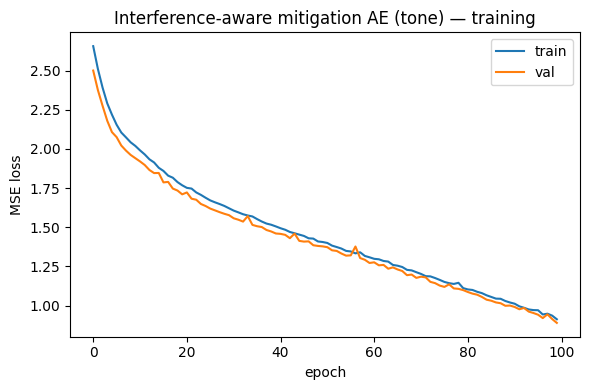

Final val_loss: 0.88902  (vs identity baseline 2.79393)


In [33]:
# Cell 8 — full training: interference-aware mitigation AE (tone)
model_mit_tone, history_mit_tone = train_mitigation_ae(
    model_mit_tone, X_train_mit, Y_train_mit, X_val_mit, Y_val_mit, device,
    epochs=100, batch_size=32, lr=3e-5, patience=15  # smaller batch given much longer sequences
)

plt.figure(figsize=(6,4))
plt.plot(history_mit_tone["train_loss"], label="train")
plt.plot(history_mit_tone["val_loss"], label="val")
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.legend()
plt.title("Interference-aware mitigation AE (tone) — training")
plt.tight_layout()
plt.savefig("figures/mitigation_ae_tone_training.png", dpi=150)
plt.show()

torch.save(model_mit_tone.state_dict(), "checkpoints/mitigation_ae_tone.pt")
print(f"Final val_loss: {history_mit_tone['val_loss'][-1]:.5f}  (vs identity baseline {identity_mse_mit:.5f})")

Eb/N0=0dB  interference=0.3392  mitigated=0.4186  clean=0.1596  theoretical=0.0786
Eb/N0=1dB  interference=0.3174  mitigated=0.4404  clean=0.1316  theoretical=0.0563
Eb/N0=2dB  interference=0.3199  mitigated=0.4545  clean=0.1044  theoretical=0.0375
Eb/N0=3dB  interference=0.3352  mitigated=0.4679  clean=0.0794  theoretical=0.0229
Eb/N0=4dB  interference=0.3226  mitigated=0.4737  clean=0.0561  theoretical=0.0125
Eb/N0=5dB  interference=0.3175  mitigated=0.4810  clean=0.0372  theoretical=0.0060
Eb/N0=6dB  interference=0.3043  mitigated=0.4956  clean=0.0232  theoretical=0.0024


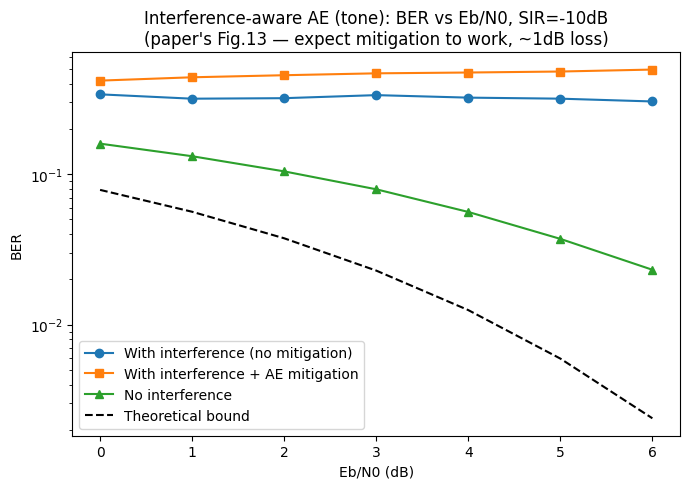

In [34]:
# Cell 9 — BER test: interference-aware AE (tone), full window N_SYMBOLS_MITIGATION=1024
SIR_DB_TEST = -10.0  # BASE-PAPER FACT (Fig.13 uses SIR=-10dB)
EBN0_RANGE = [0, 1, 2, 3, 4, 5, 6]  # BASE-PAPER FACT
N_TRIALS_MIT = 100  # fewer trials given the much heavier per-sample cost at 1024 symbols

ber_results_mit = []
for ebn0_db in EBN0_RANGE:
    snr_db = ebn0_db - 10*np.log10(cfg.NSPS)

    ber_interference, ber_mitigated, ber_clean = [], [], []
    for _ in range(N_TRIALS_MIT):
        d = mix_signal(cfg, N_SYMBOLS_MITIGATION, rng, interference_type="tone", contamination=1.0,
                        sir_db_range=(SIR_DB_TEST, SIR_DB_TEST), snr_db_range=(snr_db, snr_db), apply_shift=False)
        x, bits, fd, phi_m, k_shift = d["x"], d["bits"], d["fd"], d["phi_m"], d["k_shift"]

        ber_interference.append(matched_filter_ber(x, bits, cfg, N_SYMBOLS_MITIGATION, fd, phi_m, k_shift))

        x_mitigated = ae_denoise(x, model_mit_tone, device)
        ber_mitigated.append(matched_filter_ber(x_mitigated, bits, cfg, N_SYMBOLS_MITIGATION, fd, phi_m, k_shift))

        d_clean = mix_signal(cfg, N_SYMBOLS_MITIGATION, rng, interference_type="tone", contamination=0.0,
                              snr_db_range=(snr_db, snr_db), apply_shift=False)
        ber_clean.append(matched_filter_ber(d_clean["x"], d_clean["bits"], cfg, N_SYMBOLS_MITIGATION,
                                              d_clean["fd"], d_clean["phi_m"], d_clean["k_shift"]))

    ber_results_mit.append({
        "ebn0_db": ebn0_db,
        "ber_with_interference": np.mean(ber_interference),
        "ber_mitigated": np.mean(ber_mitigated),
        "ber_no_interference": np.mean(ber_clean),
        "ber_theoretical": theoretical_ber(ebn0_db),
    })
    print(f"Eb/N0={ebn0_db}dB  interference={np.mean(ber_interference):.4f}  "
          f"mitigated={np.mean(ber_mitigated):.4f}  clean={np.mean(ber_clean):.4f}  "
          f"theoretical={theoretical_ber(ebn0_db):.4f}")

ber_df_mit = pd.DataFrame(ber_results_mit)
ber_df_mit.to_csv("results/step8b_tone_mitigation_ber.csv", index=False)

plt.figure(figsize=(7,5))
plt.semilogy(ber_df_mit["ebn0_db"], ber_df_mit["ber_with_interference"], marker='o', label="With interference (no mitigation)")
plt.semilogy(ber_df_mit["ebn0_db"], ber_df_mit["ber_mitigated"], marker='s', label="With interference + AE mitigation")
plt.semilogy(ber_df_mit["ebn0_db"], ber_df_mit["ber_no_interference"], marker='^', label="No interference")
plt.semilogy(ber_df_mit["ebn0_db"], ber_df_mit["ber_theoretical"], linestyle='--', color='black', label="Theoretical bound")
plt.xlabel("Eb/N0 (dB)"); plt.ylabel("BER")
plt.title("Interference-aware AE (tone): BER vs Eb/N0, SIR=-10dB\n(paper's Fig.13 — expect mitigation to work, ~1dB loss)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/step8b_tone_mitigation_ber.png", dpi=150)
plt.show()